# Helsingfors Baseline Analysis

Demonstrates that Helsingfors consumption is trivially predictable, justifying its exclusion from the global model.

Helsingfors: 6289 rows, 2022-07-14 -> 2023-04-02
Test window: 2023-03-20 -> 2023-04-02 (334 rows)

Helsingfors Baseline — median(lag 5d,..,10d) predictions
  MAE:   0.0651 MW
  RMSE:  0.0843 MW
  SMAPE: 1.03%

Saved 334 predictions to helsingfors_baseline_predictions.csv


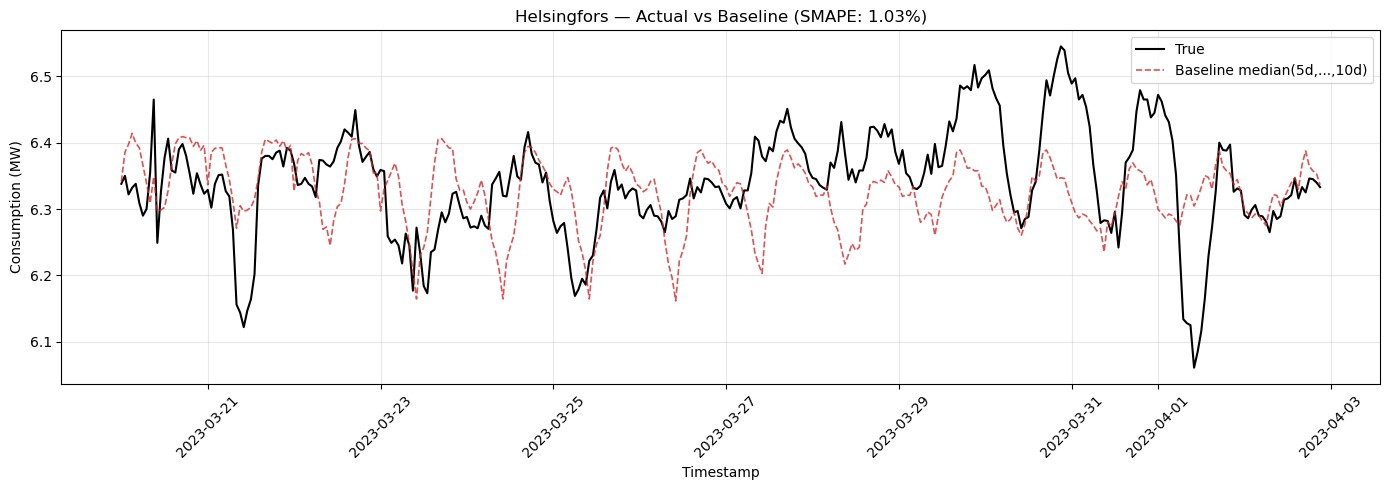

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load and filter ---
df = pd.read_csv('consumption_temp.csv')
df["datetime"] = pd.to_datetime(df["time"])
df["location"] = df["location"].astype(str).str.strip().str.lower()
df = df.set_index("datetime").sort_index()

hels = df[df["location"] == "helsingfors"].copy()
print(f"Helsingfors: {len(hels)} rows, {hels.index.min().date()} -> {hels.index.max().date()}")


# --- Metrics ---
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def smape(y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return float(np.mean(np.abs(y_true - y_pred) / denom)) * 100.0


# --- Test window: last 14 days ---
last_day = hels.index.max().normalize()
test_start = last_day - pd.Timedelta(days=13)
test_data = hels[(hels.index >= test_start) & (hels.index <= last_day + pd.Timedelta(hours=23))]

print(f"Test window: {test_start.date()} -> {last_day.date()} ({len(test_data)} rows)")


# --- Baseline: median of lag 5d, 7d, 9d ---
lookup = hels["consumption"]

rows = []
for ts in test_data.index:
    y_true = test_data.loc[ts, "consumption"]

    lag_5d = lookup.get(ts - pd.Timedelta(hours=120), np.nan)
    lag_6d = lookup.get(ts - pd.Timedelta(hours=144), np.nan)
    lag_7d = lookup.get(ts - pd.Timedelta(hours=168), np.nan)
    lag_8d = lookup.get(ts - pd.Timedelta(hours=192), np.nan)
    lag_9d = lookup.get(ts - pd.Timedelta(hours=216), np.nan)
    lag_10d = lookup.get(ts - pd.Timedelta(hours=240), np.nan)

    lags = [v for v in [lag_5d, lag_6d, lag_7d, lag_8d, lag_9d, lag_10d] if not np.isnan(v)]
    y_pred = np.median(lags) if lags else np.nan

    rows.append({
        "timestamp": ts,
        "y_true": y_true,
        "y_pred": y_pred,
        "lag_5d": lag_5d,
        "lag_6d": lag_6d,
        "lag_7d": lag_7d,
        "lag_8d": lag_8d,
        "lag_9d": lag_9d,
        "lag_10d": lag_10d,
    })

predictions = pd.DataFrame(rows).dropna(subset=["y_pred"])


# --- Results ---
print(f"\nHelsingfors Baseline — median(lag 5d,..,10d) predictions")
print(f"  MAE:   {mae(predictions['y_true'], predictions['y_pred']):.4f} MW")
print(f"  RMSE:  {rmse(predictions['y_true'], predictions['y_pred']):.4f} MW")
print(f"  SMAPE: {smape(predictions['y_true'], predictions['y_pred']):.2f}%")


# --- Save ---
predictions.to_csv("helsingfors_baseline_predictions.csv", index=False)
print(f"\nSaved {len(predictions)} predictions to helsingfors_baseline_predictions.csv")


# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(predictions["timestamp"], predictions["y_true"],
        color="black", label="True", linewidth=1.5)
ax.plot(predictions["timestamp"], predictions["y_pred"],
        color="tab:red", label="Baseline median(5d,...,10d)",
        linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_title(f"Helsingfors — Actual vs Baseline "
             f"(SMAPE: {smape(predictions['y_true'], predictions['y_pred']):.2f}%)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consumption (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()